### Cài đặt thư viện cần thiết

Cell này cài các gói dùng cho fine-tuning, lượng tử hóa, huấn luyện và giao diện chat.

In [ ]:
!pip install -U transformers datasets peft trl bitsandbytes accelerate matplotlib gradio

### Nhập các thư viện chính

Cell này nạp PyTorch, matplotlib, Gradio, tokenizer và các thành phần PEFT/QLoRA để chuẩn bị cho huấn luyện.

In [ ]:
import torch
import matplotlib.pyplot as plt
import gradio as gr

from google.colab import drive
from datasets import load_from_disk
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
from trl import SFTTrainer, SFTConfig


### Mount Drive và giải nén dữ liệu

Cell này kết nối Google Drive và giải nén bộ dữ liệu train đã tải lên sẵn.

In [ ]:
# Mở khóa (mount) Drive (nếu ô trước báo Mounted rồi thì không cần chạy lại dòng drive.mount)
drive.mount('/content/drive')

# 1. Giải nén tập Train (File bạn đã tải lên)
!unzip "/content/drive/MyDrive/Medical_Chatbot/medical_data_train.zip" -d "/content/"


Mounted at /content/drive
Archive:  /content/drive/MyDrive/Medical_Chatbot/medical_data_train.zip
   creating: /content/medical_data_train/
  inflating: /content/medical_data_train/data-00000-of-00001.arrow  
  inflating: /content/medical_data_train/dataset_info.json  
  inflating: /content/medical_data_train/state.json  
   creating: /content/medical_data_val/
  inflating: /content/medical_data_val/data-00000-of-00001.arrow  
  inflating: /content/medical_data_val/dataset_info.json  
  inflating: /content/medical_data_val/state.json  


### Tải dữ liệu và cấu hình QLoRA

Cell này nạp dataset đã tiền xử lý, cấu hình 4-bit quantization, tải Qwen2.5-1.5B-Instruct và gắn LoRA.

In [ ]:
# 1. LOAD DỮ LIỆU ĐÃ TIỀN XỬ LÝ
# (Đường dẫn này là thư mục bạn đã lưu ở file preprocessing)
train_dataset = load_from_disk("/content/medical_data_train")
val_dataset = load_from_disk("/content/medical_data_val")

# 2. CẤU HÌNH LƯỢNG TỬ HÓA 4-BIT (QLoRA)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 # Dùng float16 nếu GPU không hỗ trợ bfloat16
)

# 3. TẢI MÔ HÌNH VÀ TOKENIZER
# model_id = "Qwen/Qwen2-7B-Instruct"
model_id = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto", # Tự động chia VRAM GPU
    trust_remote_code=True,
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

# 4. CẤU HÌNH LORA (Như đã viết trong báo cáo)
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj"]
)
model = get_peft_model(model, peft_config)
# print(f"Tổng số tham số cần huấn luyện: {model.get_trainable_parameters()}")
model.print_trainable_parameters()



# 5. CẤU HÌNH SIÊU THAM SỐ HUẤN LUYỆN
sft_config = SFTConfig(
    output_dir="./medical_chatbot_results",
    num_train_epochs=1,                     # GIẢM: 1 Epoch là đủ cho dataset 60.000 dòng
    per_device_train_batch_size=8,          # TĂNG: Tận dụng VRAM của A100
    gradient_accumulation_steps=2,          # GIẢM: Để giữ Effective Batch Size = 16
    learning_rate=2e-4,
    optim="adamw_torch",
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    save_strategy="epoch",
    eval_strategy="steps",
    eval_steps=500,                         # TĂNG: Tránh việc mô hình phải dừng lại test quá nhiều lần
    logging_strategy="steps",
    logging_steps=10,
    bf16=True,
    push_to_hub=False,
    dataset_text_field="text",
    max_length=2048,                        # GIỮ NGUYÊN ĐỘ DÀI CHO DATA Y TẾ
)

# 6. KHỞI TẠO TRAINER VÀ BẮT ĐẦU HUẤN LUYỆN
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    args=sft_config,
)

print("Bắt đầu huấn luyện...")
trainer.train()

# 7. LƯU MÔ HÌNH VÀO DRIVE SAU KHI XONG
trainer.save_model("/content/drive/MyDrive/Medical_Chatbot/medical_chatbot_final_adapter")
print("Hoàn tất huấn luyện và đã lưu mô hình vào Google Drive!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/tmp/ipykernel_3152/600673430.py:58: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  sft_config = SFTConfig(
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410
Bắt đầu huấn luyện...


Step,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
500,1.669091,1.668752,1.708506,0.624633,10849089.000000
1000,1.629830,1.639927,1.687806,0.629152,21462400.000000
1500,1.613885,1.627218,1.666287,0.631325,32225812.000000
2000,1.624089,1.620998,1.658066,0.632282,42970037.000000
2500,1.625606,1.618729,1.658698,0.632724,53708375.000000
3000,1.620470,1.618066,1.657647,0.632834,64654952.000000
3500,1.626763,1.618032,1.657187,0.632800,75452334.000000
3721,1.627087,1.618036,1.657126,0.632848,80195461.000000


Hoàn tất huấn luyện và đã lưu mô hình vào Google Drive!


### Huấn luyện mô hình và lưu adapter

Cell này khởi tạo SFTTrainer, chạy fine-tuning và lưu adapter đã huấn luyện lên Drive.

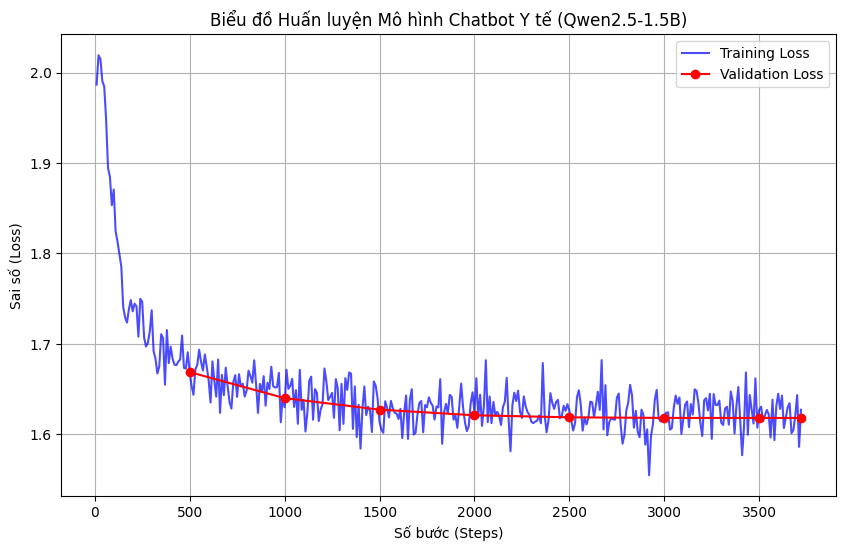

In [ ]:
# 1. Trích xuất lịch sử log từ Trainer
history = trainer.state.log_history

# 2. Tách dữ liệu Training Loss và Validation Loss
train_steps, train_loss = [], []
val_steps, val_loss = [], []

for log in history:
    if "loss" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])
    elif "eval_loss" in log:
        val_steps.append(log["step"])
        val_loss.append(log["eval_loss"])

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", color="blue", alpha=0.7)
plt.plot(val_steps, val_loss, label="Validation Loss", color="red", marker="o")

plt.title("Biểu đồ Huấn luyện Mô hình Chatbot Y tế (Qwen2.5-1.5B)")
plt.xlabel("Số bước (Steps)")
plt.ylabel("Sai số (Loss)")
plt.legend()
plt.grid(True)
plt.show()


### Vẽ biểu đồ loss

Cell này lấy log từ Trainer và vẽ đường cong training loss cùng validation loss.

### Nhận xét Biểu đồ Huấn luyện (Learning Curve)

1. **Mô hình có hội tụ không?** * **Có, hội tụ rất tốt.** Sai số (Loss) giảm mạnh ở 500 bước đầu và bắt đầu ổn định (đi ngang) từ bước 2000 trở đi ở mức ~1.61. Dừng huấn luyện ở 1 Epoch lúc này là điểm dừng hoàn hảo.
2. **Có bị dao động mạnh không?** * **Không.** Đường Training (màu xanh) có dao động dạng răng cưa nhẹ do kích thước mẻ dữ liệu (Batch Size) nhỏ, đây là hiện tượng bình thường khi train với tài nguyên giới hạn. Ngược lại, đường Validation (màu đỏ) giảm rất mượt mà.
3. **Hiện tượng Overfitting (Học vẹt):** * **Hoàn toàn không.** Đường Validation bám cực kỳ sát đường Training từ đầu đến cuối và không có dấu hiệu ngóc đầu tăng ngược trở lại. Điều này chứng tỏ mô hình học được kiến thức thực sự chứ không bị học thuộc lòng.


In [ ]:
# 1. Đường dẫn
base_model_id = "Qwen/Qwen2.5-1.5B-Instruct"
adapter_path = "/content/drive/MyDrive/Medical_Chatbot/medical_chatbot_final_adapter"

print("Đang tải Base Model...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    dtype=torch.bfloat16, # Dùng bfloat16 cho nhanh và nhẹ
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

print("Đang gắn kiến thức Y tế (LoRA)...")
model = PeftModel.from_pretrained(base_model, adapter_path)
model.eval() # Chuyển sang chế độ suy luận

# 2. Hàm trò chuyện chuẩn hóa
def chat_with_bot(user_message):
    messages = [
        {"role": "system", "content": "Bạn là một trợ lý y tế ảo hữu ích, an toàn và chuyên nghiệp."},
        {"role": "user", "content": user_message}
    ]

    # Qwen cần format prompt theo template riêng của hãng
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512, # Độ dài câu trả lời tối đa
        temperature=0.3,    # Giảm tính sáng tạo, tăng tính chính xác (phù hợp y tế)
        top_p=0.9
    )

    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response

# 3. Test thử ngay một câu hỏi!
cau_hoi = "Chào bác sĩ, dạo gần đây tôi hay bị đau nửa đầu bên phải và buồn nôn, tôi nên làm gì?"
print(f"Người bệnh: {cau_hoi}")
print("-" * 50)
print(f"Chatbot: {chat_with_bot(cau_hoi)}")


Đang tải Base Model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Đang gắn kiến thức Y tế (LoRA)...
Người bệnh: Chào bác sĩ, dạo gần đây tôi hay bị đau nửa đầu bên phải và buồn nôn, tôi nên làm gì?
--------------------------------------------------
Chatbot: Chào bạn! Bác sĩ sẽ tư vấn cho bạn như sau: Bạn có thể uống thuốc giảm đau và chống viêm theo chỉ định của bác sĩ. Nếu không cải thiện hoặc có dấu hiệu nặng hơn thì bạn cần đến khám tại các cơ sở y tế gần nhất để được thăm khám và điều trị kịp thời. Nếu bạn đang gặp phải những triệu chứng trên mà chưa biết nguyên nhân gây ra, bạn cũng nên đi khám để được chẩn đoán chính xác và điều trị kịp thời.


### Nạp adapter và thử suy luận

Cell này tải base model, gắn LoRA đã huấn luyện và thử trả lời một câu hỏi mẫu.

In [ ]:
# Hàm bọc lại logic chat để tương thích với Gradio
def gradio_chat(message, history):
    # message: Câu hỏi mới nhất của người dùng
    # Gọi lại hàm chat_with_bot mà bạn đã viết ở trên
    return chat_with_bot(message)

# Thiết lập giao diện
demo = gr.ChatInterface(
    fn=gradio_chat,
    title="🩺 Trợ lý Y tế Ảo (Qwen 1.5B Fine-tuned)",
    description="Chatbot hỗ trợ tư vấn y tế cơ bản. Lưu ý: Thông tin chỉ mang tính chất tham khảo, không thay thế chỉ định của bác sĩ.",
    theme="soft",
    examples=["Tôi bị sốt 39 độ và ho khan 2 ngày nay, nên uống thuốc gì?",
              "Làm thế nào để phòng ngừa bệnh sốt xuất huyết?"]
)

# Khởi chạy web (share=True sẽ tạo một đường link Public)
demo.launch(share=True)


/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c56dcd83880d33f515.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
